In [ ]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

# Load datasets (update path if needed)
purchase_df = pd.read_csv('customer_purchase_data.csv')
reviews_df = pd.read_csv('customer_reviews_data.csv')

# Quick inspection
print("Purchase data shape:", purchase_df.shape)
print("Review data shape:", reviews_df.shape)

# Display first few rows
display(purchase_df.head(3))
display(reviews_df.head(3))


Purchase data shape: (1000, 10)
Review data shape: (1000, 5)


,TransactionID,CustomerID,CustomerName,ProductID,ProductName,ProductCategory,PurchaseQuantity,PurchasePrice,PurchaseDate,Country
0,1,887,Kenneth Martinez,240,Router,Electronics,5,689.99,2024-03-01,Barbados
1,2,560,Joseph Anderson,299,Camera,Electronics,4,79.27,2024-01-26,Northern Mariana Islands
2,3,701,Vincent Reynolds,207,Electric Kettle,Home Appliances,3,666.75,2024-05-13,British Virgin Islands


,ReviewID,CustomerID,ProductID,ReviewText,ReviewDate
0,1,486,267,So impressed by the quality. This product trul...,5/12/2024
1,2,810,246,I'm very happy with the performance. It does e...,3/7/2024
2,3,855,291,I regret buying this. The quality is terrible ...,11/15/2023


In [ ]:
# Clean purchase data
purchase_df = purchase_df.dropna(subset=['ProductID', 'PurchaseQuantity', 'PurchasePrice'])
purchase_df['PurchaseDate'] = pd.to_datetime(purchase_df['PurchaseDate'], errors='coerce')

# Compute total revenue
purchase_df['Revenue'] = purchase_df['PurchaseQuantity'] * purchase_df['PurchasePrice']

# Clean review data
reviews_df = reviews_df.dropna(subset=['ReviewText'])
reviews_df['ReviewText'] = reviews_df['ReviewText'].astype(str)
reviews_df['ReviewDate'] = pd.to_datetime(reviews_df['ReviewDate'], errors='coerce')

# Check missing values
print("Missing values in purchase data:\n", purchase_df.isna().sum())
print("\nMissing values in review data:\n", reviews_df.isna().sum())


Missing values in purchase data:
 TransactionID       0
CustomerID          0
CustomerName        0
ProductID           0
ProductName         0
ProductCategory     0
PurchaseQuantity    0
PurchasePrice       0
PurchaseDate        0
Country             0
Revenue             0
dtype: int64

Missing values in review data:
 ReviewID      0
CustomerID    0
ProductID     0
ReviewText    0
ReviewDate    0
dtype: int64


In [ ]:
# Compute sentiment polarity using TextBlob
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

reviews_df['Polarity'] = reviews_df['ReviewText'].apply(get_sentiment)

# Categorize sentiment
def label_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

reviews_df['Sentiment'] = reviews_df['Polarity'].apply(label_sentiment)

# Check sample output
reviews_df[['ProductID', 'ReviewText', 'Polarity', 'Sentiment']].head()


,ProductID,ReviewText,Polarity,Sentiment
0,267,So impressed by the quality. This product trul...,1.000000,Positive
1,246,I'm very happy with the performance. It does e...,0.625000,Positive
2,291,I regret buying this. The quality is terrible ...,-1.000000,Negative
3,235,"It serves its purpose, but it's not anything e...",0.333333,Positive
4,220,Very high-quality product. I would buy it agai...,0.200000,Positive


In [ ]:
# Merge on ProductID
purchase_df['ProductID'] = purchase_df['ProductID'].astype(str)
reviews_df['ProductID'] = reviews_df['ProductID'].astype(str)

merged_df = pd.merge(reviews_df, purchase_df, on='ProductID', how='inner')

print("Merged shape:", merged_df.shape)
display(merged_df.head())


Merged shape: (10109, 17)


,ReviewID,CustomerID_x,ProductID,ReviewText,ReviewDate,Polarity,Sentiment,TransactionID,CustomerID_y,CustomerName,ProductName,ProductCategory,PurchaseQuantity,PurchasePrice,PurchaseDate,Country,Revenue
0,1,486,267,So impressed by the quality. This product trul...,2024-05-12,1.0,Positive,73,980,Christopher Medina,Television,Electronics,2,741.22,2023-08-14,Saint Lucia,1482.44
1,1,486,267,So impressed by the quality. This product trul...,2024-05-12,1.0,Positive,104,775,Aaron Arnold Jr.,Microwave,Home Appliances,5,441.53,2024-04-01,Falkland Islands (Malvinas),2207.65
2,1,486,267,So impressed by the quality. This product trul...,2024-05-12,1.0,Positive,111,439,Shannon Davis,Coffee Maker,Home Appliances,1,195.71,2024-06-16,Armenia,195.71
3,1,486,267,So impressed by the quality. This product trul...,2024-05-12,1.0,Positive,258,251,Sylvia Schroeder,Camera,Electronics,1,336.39,2024-05-25,Haiti,336.39
4,1,486,267,So impressed by the quality. This product trul...,2024-05-12,1.0,Positive,523,567,Madison Elliott,Blender,Home Appliances,3,419.67,2024-02-29,Northern Mariana Islands,1259.01


Monthly Polarity vs Revenue correlation: 0.282629975711969


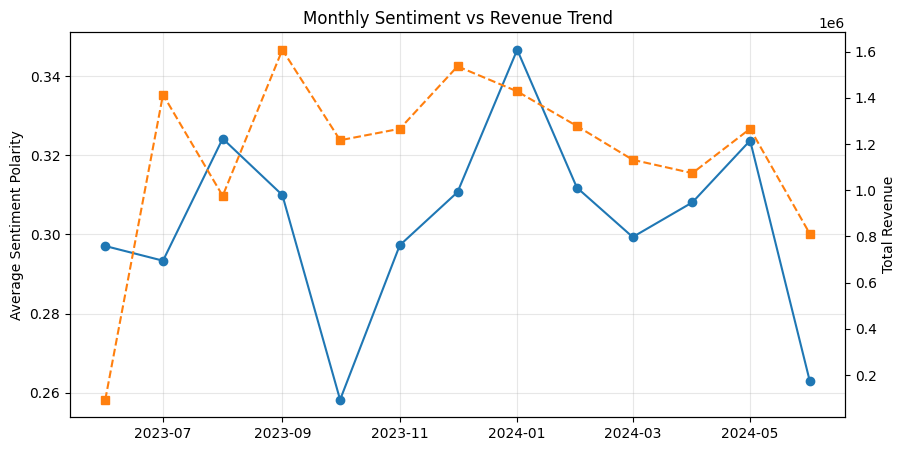

In [ ]:
# Aggregate monthly polarity & revenue
merged_df['Month'] = pd.to_datetime(merged_df['PurchaseDate']).dt.to_period('M').dt.to_timestamp()

agg = merged_df.groupby('Month').agg({
    'Polarity': 'mean',
    'Revenue': 'sum'
}).reset_index()

# Correlation
corr = agg['Polarity'].corr(agg['Revenue'])
print("Monthly Polarity vs Revenue correlation:", corr)

# Plot
fig, ax = plt.subplots(figsize=(10,5))
ax2 = ax.twinx()
ax.plot(agg['Month'], agg['Polarity'], color='tab:blue', marker='o', label='Avg Polarity')
ax2.plot(agg['Month'], agg['Revenue'], color='tab:orange', marker='s', linestyle='--', label='Revenue')
ax.set_ylabel('Average Sentiment Polarity')
ax2.set_ylabel('Total Revenue')
ax.set_title('Monthly Sentiment vs Revenue Trend')
ax.grid(True, alpha=0.3)
plt.show()


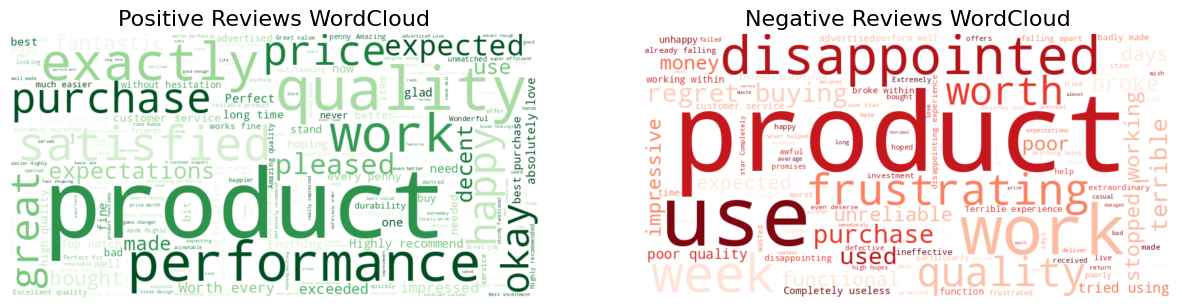

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Separate reviews by sentiment
pos_reviews = " ".join(reviews_df[reviews_df['Sentiment'] == 'Positive']['ReviewText'])
neg_reviews = " ".join(reviews_df[reviews_df['Sentiment'] == 'Negative']['ReviewText'])

# WordClouds
stopwords = set(STOPWORDS)

plt.figure(figsize=(15,7))
plt.subplot(1,2,1)
wc_pos = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords, colormap='Greens').generate(pos_reviews)
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Reviews WordCloud', fontsize=16)

plt.subplot(1,2,2)
wc_neg = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords, colormap='Reds').generate(neg_reviews)
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Reviews WordCloud', fontsize=16)

plt.show()


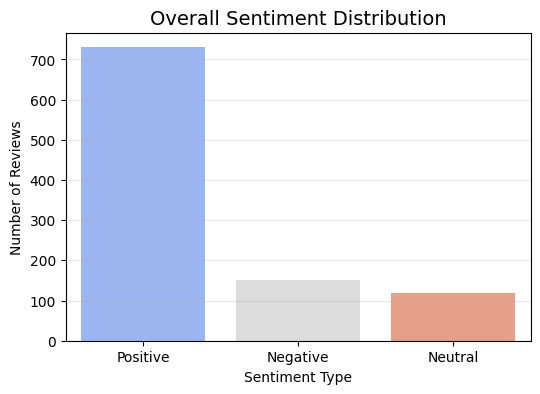

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=reviews_df, x='Sentiment', palette='coolwarm')
plt.title('Overall Sentiment Distribution', fontsize=14)
plt.xlabel('Sentiment Type')
plt.ylabel('Number of Reviews')
plt.grid(axis='y', alpha=0.3)
plt.show()


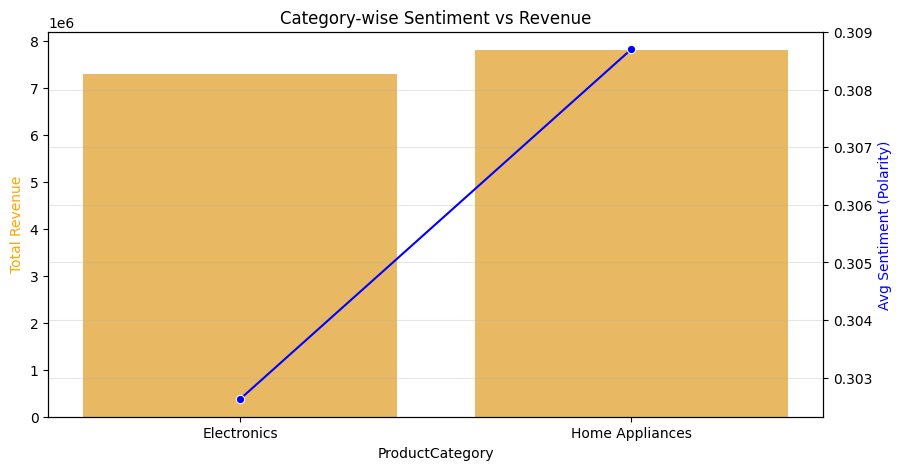

In [ ]:
# Merge sentiment & purchase data by ProductCategory
category_sent = merged_df.groupby('ProductCategory').agg({
    'Polarity': 'mean',
    'Revenue': 'sum'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(10,5))
ax2 = ax1.twinx()

sns.barplot(x='ProductCategory', y='Revenue', data=category_sent, ax=ax1, alpha=0.7, color='orange')
sns.lineplot(x='ProductCategory', y='Polarity', data=category_sent, ax=ax2, color='blue', marker='o')

ax1.set_ylabel('Total Revenue', color='orange')
ax2.set_ylabel('Avg Sentiment (Polarity)', color='blue')
ax1.set_title('Category-wise Sentiment vs Revenue')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()


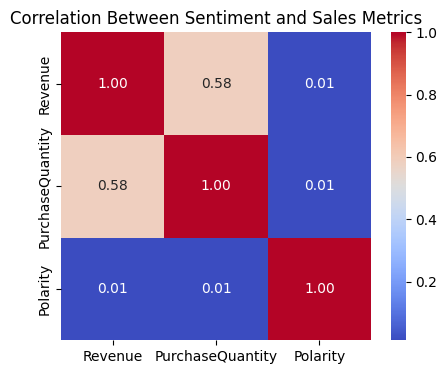

In [ ]:
numeric_cols = merged_df[['Revenue', 'PurchaseQuantity', 'Polarity']]
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Sentiment and Sales Metrics')
plt.show()


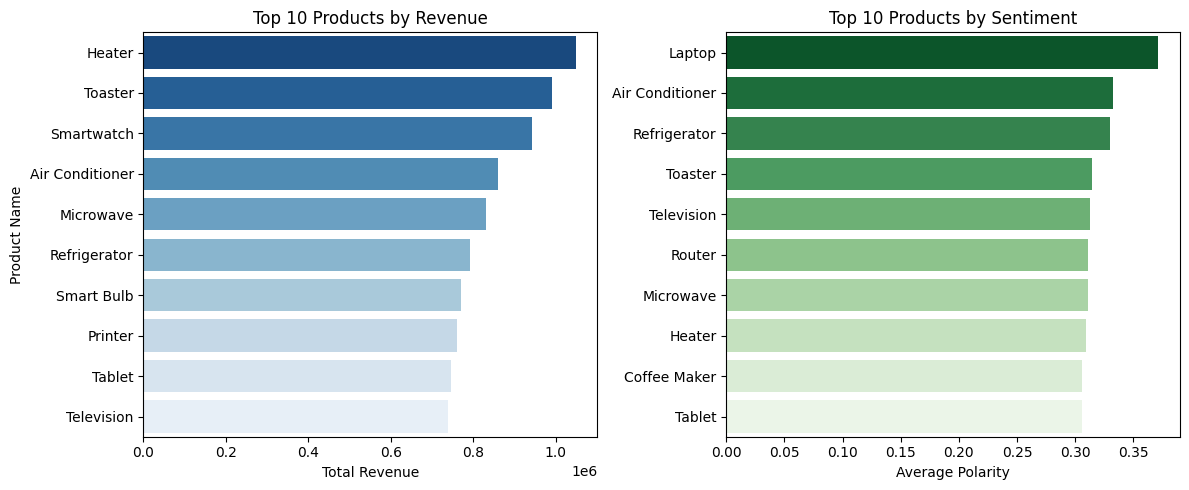

In [ ]:
# Top 10 by revenue
top_revenue = merged_df.groupby('ProductName')['Revenue'].sum().sort_values(ascending=False).head(10)
top_sentiment = merged_df.groupby('ProductName')['Polarity'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.barplot(y=top_revenue.index, x=top_revenue.values, palette='Blues_r')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product Name')

plt.subplot(1,2,2)
sns.barplot(y=top_sentiment.index, x=top_sentiment.values, palette='Greens_r')
plt.title('Top 10 Products by Sentiment')
plt.xlabel('Average Polarity')
plt.ylabel('')
plt.tight_layout()
plt.show()


In [ ]:
# Top 5 Positive Products
top_pos = merged_df.groupby('ProductName')['Polarity'].mean().sort_values(ascending=False).head(5)
print("Top Positive Products:\n", top_pos)

# Top 5 Negative Products
top_neg = merged_df.groupby('ProductName')['Polarity'].mean().sort_values(ascending=True).head(5)
print("\nTop Negative Products:\n", top_neg)

# Export for Power BI Dashboard
merged_df.to_csv('merged_customer_sentiment_sales.csv', index=False)
print("\n✅ Final merged dataset exported as 'merged_customer_sentiment_sales.csv'")


Top Positive Products:
 ProductName
Laptop             0.371391
Air Conditioner    0.332577
Refrigerator       0.330192
Toaster            0.314087
Television         0.312889
Name: Polarity, dtype: float64

Top Negative Products:
 ProductName
Camera        0.266803
Blender       0.268713
Headphones    0.283803
Smartwatch    0.288224
Smart Bulb    0.292064
Name: Polarity, dtype: float64

✅ Final merged dataset exported as 'merged_customer_sentiment_sales.csv'
